# 1 Visualizing OPM MEG Data with MNE-Python

This notebook covers how to visualize OPM MEG data at two levels:

**Part I — Continuous Raw Data (Sections 1–5):** Loading the raw FIF file,
exploring the `Raw` object structure, reading and plotting events, interactively
browsing the full time series, and inspecting spectral density of the continuous recording.
Adapted from the MNE tutorials on
[Raw data structure](https://mne.tools/stable/auto_tutorials/raw/10_raw_overview.html) and
[Built-in plotting methods for Raw objects](https://mne.tools/stable/auto_tutorials/raw/40_visualize_raw.html).

**Part II — Epoched Data (Sections 6–14):** Visualizing the cleaned, epoched data
using time-series browsers, butterfly plots, spectral topographies, epoch image maps,
and topo image maps. Adapted from the
[MNE Visualizing Epoched Data tutorial](https://mne.tools/stable/auto_tutorials/epochs/20_visualize_epochs.html).

In both parts we use real OPM MEG data from our passive auditory oddball paradigm
(sub-001, ses-01) rather than the MNE sample dataset.

---
### Paradigm design

| Parameter | Value |
|-----------|-------|
| Standard tone | 1000 Hz |
| Deviant tone | 1200 Hz |
| Tone duration | 400 ms (50 ms rise/fall ramps) |
| Total trials | 1000 (~84% standard, ~16% deviant) |
| Deviant count | ~160, separated by 3–7 standards (mean gap 5.1 ± 1.3) |
| ISI | 700–900 ms jittered (~25 discrete bins of ~8.33 ms) |
| Mean trial duration | 1200 ms (400 ms tone + 800 ms mean ISI) |
| Onset-to-onset range | 1100–1300 ms |
| Total recording | ~24 min |
| Task | Passive fixation (central fixation cross) |
| Opening sequence | First 10 trials are all standards (establish regularity) |

**Blink trials:** One blink opportunity follows each deviant (~162 total). A green fixation
cross appears for 1.5 s. The blink cue onset is at least 1100 ms after deviant onset —
well after the MMN window (100–250 ms post-deviant) — so blink artifacts do not
contaminate the MMN response of interest.

**Conditions in this epochs file:**
- `standard_onset` — frequent 1000 Hz tones (~840 trials before rejection)
- `deviant_onset` — rare 1200 Hz tones (~160 trials before rejection), the MMN-eliciting stimuli

---
### Running this notebook in the mne-opm environment

This notebook is designed to run inside the `mne-opm` project environment. Launch it with:

```bash
uv run --project $MNE_OPM_DIR jupyter lab
# or
uv run --project $MNE_OPM_DIR jupyter notebook
```

Once open, make sure the kernel matches the mne-opm Python interpreter (it should select it automatically if launched this way).

For **interactive** plot windows (scrollable raw browser, scrollable epochs browser), run cells from a terminal using:
```bash
uv run --project $MNE_OPM_DIR python -c "..."
```
or use `%matplotlib qt` instead of `%matplotlib inline` below. Interactive mode is strongly
recommended for `raw.plot()` and `epochs.plot()` — it allows scrolling, zooming, and
marking bad channels/epochs in real time.

## 0. Setup

In [1]:
# Use inline static figures for notebook rendering.
# Switch to %matplotlib qt for interactive scrollable plots (e.g. epochs.plot())
%matplotlib inline
#%matplotlib qt

import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import mne

mne.set_log_level('WARNING')  # reduce console noise
print(f'MNE version: {mne.__version__}')

MNE version: 0.1.0.dev18586+g806b593c4


In [2]:
# ─── USER SETTINGS ───────────────────────────────────────────────────────────
DERIV_DIR = pathlib.Path('path/to/oddball/data/oddball/bids/derivatives/analysis1__/sub-001/ses-01/meg')

# True (unprocessed) raw files live in the BIDS source tree, not derivatives.
# Adjust RAW_DIR and raw_fif to match your local file structure.
RAW_DIR   = pathlib.Path('path/to/oddball/data/oddball/bids/sub-001/ses-01/meg')

SUBJECT = 'sub-001'
SESSION = 'ses-01'
TASK    = 'oddball'

# Epoch condition labels (must match what was used during epoching)
STANDARD_COND = 'standard_onset'
DEVIANT_COND  = 'deviant_onset'

# ─────────────────────────────────────────────────────────────────────────────

# 1. True raw: straight off the OPM system, no filtering applied
raw_fif   = RAW_DIR  / f'{SUBJECT}_{SESSION}_task-{TASK}_run-01_split-01_meg.fif'

# 2. Filtered: bandpass (0.1–100 Hz) + 60/120/180 Hz notch, HFC-denoised
filt_fif  = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_run-01_proc-filt_raw.fif'

# 3. Clean: ICA-cleaned continuous file (adjust filename to match your pipeline output)
clean_fif = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_run-01_proc-clean_raw.fif'

# Preprocessed cleaned epochs (Part II starting point)
epo_file  = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_proc-clean_epo.fif'

for label, p in [('True raw', raw_fif), ('Filtered', filt_fif),
                 ('Clean',    clean_fif), ('Epochs',  epo_file)]:
    print(f'{label:12s}: {p.name}  [exists={p.exists()}]')

True raw    : sub-001_ses-01_task-oddball_run-01_split-01_meg.fif  [exists=True]
Filtered    : sub-001_ses-01_task-oddball_run-01_proc-filt_raw.fif  [exists=True]
Clean       : sub-001_ses-01_task-oddball_run-01_proc-clean_raw.fif  [exists=True]
Epochs      : sub-001_ses-01_task-oddball_proc-clean_epo.fif  [exists=True]


---
## Part I — Continuous Raw Data

Before looking at individual epochs, it's worth spending time with the **full continuous
recording**. The `Raw` object is MNE's representation of a time series of arbitrary length —
everything before it gets cut into stimulus-locked segments.

Starting here pays dividends:
- You see the data **as it was acquired**, including drift, slow artifacts, and the
  long gaps between trials that are invisible inside an epoch window
- You can spot **recording-level problems** (bad channels, large transients, power-line
  interference) that might not be obvious after epoching and averaging
- You learn the full **event structure** of the paradigm — every trial, every blink cue,
  every annotation left by the preprocessing pipeline

## 1. Loading Continuous Data

`mne.io.read_raw_fif()` is the entry point for any FIF-format recording. We load
three versions of the same session so we can compare how each preprocessing stage
affects the signal:

| Variable | File | Processing stage |
|----------|------|------------------|
| `raw_true` | `*_meg.fif` | Straight off the OPM system — no filtering |
| `raw` | `*_proc-filt_raw.fif` | Bandpass 0.1–100 Hz + 60/120/180 Hz notch + HFC |
| `raw_clean` | `*_proc-clean_raw.fif` | As above, plus ICA artifact removal |

`raw` (the filtered file) is the primary object used throughout sections 2–5 for
event reading, data browsing, and attribute queries — it's the most useful starting
point for those tasks. `raw_true` and `raw_clean` are loaded here and compared
in the PSD section.

All three are opened with `preload=False` — only the file headers are read into
RAM. Data is loaded on demand or explicitly via `.load_data()`.

In [3]:
# Load all three files (header only — preload=False keeps memory low)
raw_true  = mne.io.read_raw_fif(raw_fif,   preload=False)
raw       = mne.io.read_raw_fif(filt_fif,  preload=False)  # primary for browsing/events
raw_clean = mne.io.read_raw_fif(clean_fif, preload=False)

for label, r in [('True raw', raw_true), ('Filtered', raw), ('Clean', raw_clean)]:
    print(f'{label:12s}: {r}')

True raw    : <Raw | sub-001_ses-01_task-oddball_run-01_split-01_meg.fif, 215 x 1783800 (1486.5 s), ~17.8 MiB, data not loaded>
Filtered    : <Raw | sub-001_ses-01_task-oddball_run-01_proc-filt_raw.fif, 215 x 1783800 (1486.5 s), ~17.8 MiB, data not loaded>
Clean       : <Raw | sub-001_ses-01_task-oddball_run-01_proc-clean_raw.fif, 215 x 1783800 (1486.5 s), ~17.8 MiB, data not loaded>


## 2. Reading Raw FIF Information

Every MNE data object carries an `info` dictionary. This is the single source of truth
for metadata about the recording — sensor geometry, sampling rate, bad channels,
filter history, subject/date info, and more.

`print(raw.info)` gives a structured summary. The most important top-level fields for
day-to-day analysis:

| Field | Meaning |
|-------|---------|
| `sfreq` | Sampling frequency (Hz) |
| `nchan` | Total number of channels (all types) |
| `ch_names` | Ordered list of channel names |
| `bads` | Channels marked as bad (list of names) |
| `meas_date` | Date/time the recording was started |
| `highpass` / `lowpass` | Online filter cutoffs applied at acquisition |
| `dig` | Digitized head shape and fiducial points |

> **OPM note:** Each OPM slot measures up to three orthogonal field components (X, Y, Z).
> Channel names follow the pattern `LOCATION SERIAL AXIS` (e.g. `T13 2Z Z`). The `Z` axis
> is radial (normal to the scalp), `X` and `Y` are tangential.

In [4]:
print(raw.info)

<Info | 16 non-empty values
 bads: 4 items (T14 1X Z, T14 1X Y, T14 1X X, F4 2N Z)
 ch_names: BNC 1 Z, BNC 2 Z, BNC 3 Z, BNC 4 Z, BNC 5 Z, BNC 6 Z, BNC 7 Z, ...
 chs: 8 Stimulus, 192 Magnetometers, 6 Reference Magnetometers, 2 Eye-tracking (Gaze position), 1 Eye-tracking (Pupil size), 3 misc, 3 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 device_info: 2 items (dict)
 dig: 50625 items (3 Cardinal, 50622 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 line_freq: 60.0
 lowpass: 100.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 215
 projs: HFC: l=1 m=-1: on, HFC: l=1 m=0: on, HFC: l=1 m=1: on, HFC: l=2 ...
 sfreq: 1200.0 Hz
 subject_info: <subject_info | his_id: sub-001, sex: 0, hand: 0>
>


## 3. Querying the Raw Object

Beyond `info`, the `Raw` object exposes a set of computed properties that give you
quick access to the most useful scalars and arrays. You'll use these constantly
in analysis scripts.

In [5]:
from collections import Counter

print('── Timing ─────────────────────────────────────────────────────────')
print(f'  Sampling frequency : {raw.info["sfreq"]:.1f} Hz')
print(f'  First sample index : {raw.first_samp}  (samples before tmin=0)')
print(f'  Last sample index  : {raw.last_samp}')
print(f'  Total samples      : {raw.n_times}')
print(f'  Duration           : {raw.times[-1]:.1f} s  ({raw.times[-1]/60:.1f} min)')
print(f'  times array shape  : {raw.times.shape}  (start={raw.times[0]:.3f} s, '
      f'stop={raw.times[-1]:.3f} s)')
print()
print('── Channels ───────────────────────────────────────────────────────')
print(f'  Total channels : {len(raw.ch_names)}')
print(f'  Bad channels   : {raw.info["bads"] or "none"}')
ch_types = Counter(mne.channel_type(raw.info, i) for i in range(len(raw.ch_names)))
print('  Channel types  :')
for t, n in sorted(ch_types.items()):
    print(f'    {t}: {n}')
print()
print('── Filter history ─────────────────────────────────────────────────')
print(f'  Highpass : {raw.info["highpass"]:.2f} Hz')
print(f'  Lowpass  : {raw.info["lowpass"]:.1f} Hz')

── Timing ─────────────────────────────────────────────────────────
  Sampling frequency : 1200.0 Hz
  First sample index : 0  (samples before tmin=0)
  Last sample index  : 1783799
  Total samples      : 1783800
  Duration           : 1486.5 s  (24.8 min)
  times array shape  : (1783800,)  (start=0.000 s, stop=1486.499 s)

── Channels ───────────────────────────────────────────────────────
  Total channels : 215
  Bad channels   : ['T14 1X Z', 'T14 1X Y', 'T14 1X X', 'F4 2N Z']
  Channel types  :
    eog: 3
    eyegaze: 2
    mag: 192
    misc: 3
    pupil: 1
    ref_meg: 6
    stim: 8

── Filter history ─────────────────────────────────────────────────
  Highpass : 0.10 Hz
  Lowpass  : 100.0 Hz


Channel : P5 36 Z
Snippet : (1, 12000)  (1 channel × 12000 samples)
Range   : -0.99 – 1.06 pT


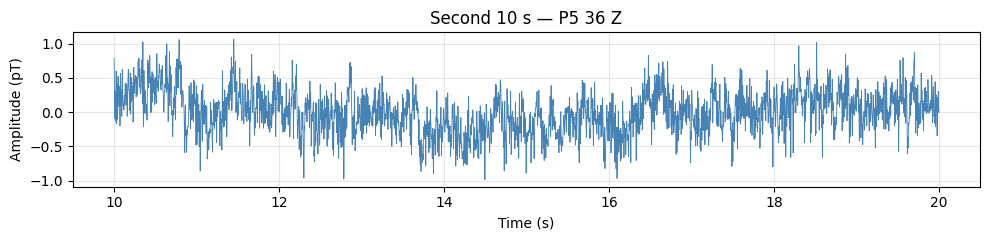

In [6]:
# Slicing raw data arrays: raw[picks, time_range]
# Returns (data, times) where data.shape = (n_picks, n_times).
# Useful for quick sanity checks without loading the full file.

# Pick a single representative Z-axis channel
ref_ch = 'P5 36 Z'   # a reliable reference channel in this dataset
ch_idx = raw.ch_names.index(ref_ch)

# Grab the second 10 seconds of data
data_snippet, times_snippet = raw[ch_idx, raw.time_as_index(10.0):raw.time_as_index(20.0)]

print(f'Channel : {ref_ch}')
print(f'Snippet : {data_snippet.shape}  (1 channel × {len(times_snippet)} samples)')
print(f'Range   : {data_snippet.min()*1e12:.2f} – {data_snippet.max()*1e12:.2f} pT')

# Quick matplotlib plot of the snippet
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(times_snippet, data_snippet[0] * 1e12, lw=0.6, color='steelblue')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (pT)')
ax.set_title(f'Second 10 s — {ref_ch}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Reading and Plotting Events

MNE represents events as an integer array of shape `(n_events, 3)`:

```
[ sample_index,  previous_event_id,  current_event_id ]
```

The middle column (`previous_event_id`) is a legacy field — it is
almost always 0 and can be ignored. The important columns are the **sample index** (when)
and the **event ID** (what).

### Two ways to get events from a raw file

**From annotations** (BIDS workflow, recommended):
When a raw file is written with BIDS-compatible annotations (e.g. after being processed by
mne-bids or mne-bids-pipeline), `mne.events_from_annotations()` extracts events from those
annotations. This is the correct path for our pipeline-preprocessed data.

**From a stimulus channel** (hardware trigger channel):
Some acquisition systems encode triggers as TTL pulses on a dedicated `STI` or `BNC` channel.
`mne.find_events(raw, stim_channel='CHANNEL_NAME')` reads those transitions directly.
For our setup, the VPIXX pixel-mode triggers go to a BNC input, so this is an alternative
path if the raw file predates BIDS annotation.

The cell below tries annotations first and falls back to `find_events` automatically.

In [7]:
# ── Read events ──────────────────────────────────────────────────────────────

# Attempt 1: events from BIDS-compatible annotations in the raw file
try:
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    if len(events) == 0:
        raise ValueError('No events found in annotations')
    print(f'Events from annotations: {len(events)} total')
    print(f'Event ID mapping: {event_id}')
    event_source = 'annotations'
except Exception as e:
    print(f'Annotations attempt: {e}')
    print('Falling back to mne.find_events (stimulus channel)...')
    # Identify any non-mag, non-ref channels that might carry triggers
    stim_chs = [ch for ch in raw.ch_names if 'BNC' in ch or 'STI' in ch]
    print(f'  Candidate stim channels: {stim_chs}')
    events = mne.find_events(raw, stim_channel=stim_chs or None, min_duration=0.002)
    event_id = {str(eid): eid for eid in np.unique(events[:, 2])}
    print(f'Events from stim channel: {len(events)} total')
    print(f'Unique event IDs: {list(event_id.keys())}')
    event_source = 'stim_channel'

# Per-condition counts
print()
for name, eid in event_id.items():
    n = (events[:, 2] == eid).sum()
    print(f'  {name:30s}: {n:4d} events')

Events from annotations: 1170 total
Event ID mapping: {np.str_('blink_trial'): 1, np.str_('deviant_onset'): 2, np.str_('no_eyetrack'): 3, np.str_('standard_onset'): 4}

  blink_trial                   :  169 events
  deviant_onset                 :  169 events
  no_eyetrack                   :    1 events
  standard_onset                :  831 events


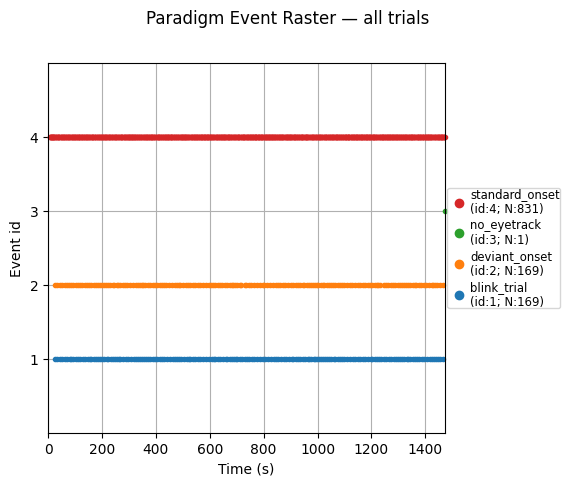

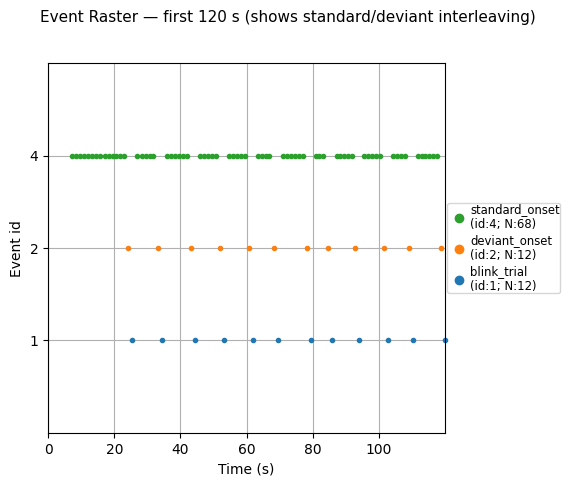

In [8]:
# ── Static event raster plot ──────────────────────────────────────────────────
# mne.viz.plot_events() draws one row per event type on a timeline.
# Each dot marks a single trial onset. This makes it easy to:
#   - confirm the total trial count and proportion of each condition
#   - spot any missing or duplicated triggers
#   - see the temporal spacing between deviant and standard events

fig = mne.viz.plot_events(
    events,
    sfreq=raw.info['sfreq'],
    first_samp=raw.first_samp,   # converts sample indices to seconds correctly
    event_id=event_id,
    show=False,
)
fig.suptitle('Paradigm Event Raster — all trials', fontsize=12)
plt.show()

# Zoom in on the first 120 seconds to see individual trial spacing
mask = events[:, 0] < raw.first_samp + int(120 * raw.info['sfreq'])
events_120 = events[mask]

# Only pass event IDs that are actually present in this time window —
# plot_events raises a ValueError if event_id references an ID not in events.
ids_present = set(events_120[:, 2])
event_id_120 = {k: v for k, v in event_id.items() if v in ids_present}

fig2 = mne.viz.plot_events(
    events_120,
    sfreq=raw.info['sfreq'],
    first_samp=raw.first_samp,
    event_id=event_id_120,
    show=False,
)
fig2.suptitle('Event Raster — first 120 s (shows standard/deviant interleaving)', fontsize=11)
plt.show()

## 5. Plotting Events and Raw Data Together

`raw.plot()` accepts an `events` array and `event_id` dict so you can see trial onset
markers overlaid on the continuous signal. Vertical colored lines appear at each event,
color-coded by condition.

This combined view is the primary tool for artifact inspection in continuous data —
you can immediately see whether transients cluster around specific event types,
or whether they occur randomly during inter-trial intervals.

### Key parameters for OPM data

**`picks='mag'`**
OPM sensors are magnetometers. Mixing in BNC, eyetracking, and stim channels
(wildly different amplitude scales) makes the mag traces unreadable.

**`scalings=dict(mag=5e-12)`**
Default MNE mag scaling is calibrated for SQUID MEG. OPM sensors are noisier
(~15 fT/√Hz floor), so 5 pT/div is a more useful starting point. Adjust live
with `+` / `-` in the browser.

**`duration=10`**
Shows 10 s per screen — enough to see ~8–10 trials at a glance.

**`start=30`**
Skips the first 30 s. The first 10 trials are all standards (paradigm warm-up),
so the first deviant typically appears around 12–15 s; starting at 30 s puts
you in the middle of normal standard/deviant interleaving immediately.

### Interactive browser keyboard shortcuts

| Key | Action |
|-----|--------|
| `←` / `→` | Scroll backward/forward in time |
| `↑` / `↓` | Scroll channels up/down |
| `+` / `-` | Scale amplitude up/down |
| `a` | Toggle annotations mode (click to add/remove annotations) |
| `b` | Toggle bad-channel marking mode (click a channel name to flag it) |
| `?` | Show full keyboard shortcut help |

> **Backend note:** In `%matplotlib inline` (Jupyter default) you get a static snapshot
> of the first `duration` seconds. Switch to `%matplotlib qt` for the full interactive
> scrollable browser, which is where `raw.plot()` really shines.

In [9]:
# Load data into RAM before plotting — required for interactive scrolling.
# (no-op if already loaded)
raw.load_data()

# Static inline snapshot — shows events as vertical lines on the raw signal.
# Switch to %matplotlib qt above for the full interactive browser.
fig = raw.plot(
    events=events,
    event_id=event_id,
    picks='mag',
    scalings=dict(mag=5e-12),   # 5 pT/div — appropriate for OPM noise floor
    n_channels=30,
    duration=10.0,              # seconds visible per screen
    start=30.0,                 # start 30 s in (first deviant typically appears ~12 s)
    show_scrollbars=True,
    show=True,
    block=False,
)
plt.show()

## 6. Plotting Spectral Density of Continuous Data

Overlaying the PSD of all three preprocessing stages on a single plot is one of
the clearest ways to see exactly what each step does to the signal:

| Trace | What it shows |
|-------|---------------|
| **True raw** (grey) | Unprocessed OPM signal — 1/f noise, 60 Hz line peaks, and low-frequency movement noise all visible |
| **Filtered** (blue) | After bandpass (0.1–100 Hz) + notch + HFC — line peaks removed, low-frequency floor raised by highpass |
| **Clean** (orange) | After ICA on top of filtering — artifact-driven peaks removed, signal-band SNR improved |

We use `n_fft=4096` for fine frequency resolution (~0.3 Hz bins at 1200 Hz sfreq),
which is much finer than what the short epoch windows allow.

In [10]:

PSD_KWARGS = dict(
    method='welch',
    picks='mag',
    fmin=1.0,
    fmax=600.0,
    n_fft=4096,
    reject_by_annotation=True,
    exclude='bads',
)

raw_true.load_data()
raw.load_data()
raw_clean.load_data()

import warnings
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='nperseg.*greater than input length')
    spectrum_true  = raw_true.compute_psd(**PSD_KWARGS)
    spectrum_filt  = raw.compute_psd(**PSD_KWARGS)
    spectrum_clean = raw_clean.compute_psd(**PSD_KWARGS)

for label, s in [('True raw', spectrum_true), ('Filtered', spectrum_filt), ('Clean', spectrum_clean)]:
    res = s.freqs[1] - s.freqs[0]
    print(f'{label:12s}: {len(s.freqs)} bins, {s.freqs[0]:.1f}–{s.freqs[-1]:.1f} Hz, '
          f'res={res:.3f} Hz, {s.get_data().shape[0]} channels')

True raw    : 2045 bins, 1.2–600.0 Hz, res=0.293 Hz, 188 channels
Filtered    : 2045 bins, 1.2–600.0 Hz, res=0.293 Hz, 188 channels
Clean       : 2045 bins, 1.2–600.0 Hz, res=0.293 Hz, 188 channels


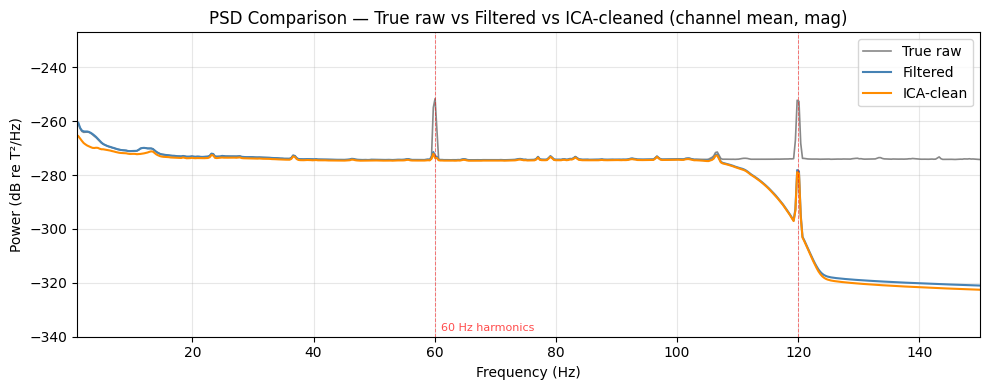

In [11]:
# Overlay all three PSDs on one axes for direct comparison.
# We compute the channel-mean manually so we can control colors and labels.

traces = [
    (spectrum_true,  'True raw',  '#888888', 1.2),
    (spectrum_filt,  'Filtered',  'steelblue', 1.5),
    (spectrum_clean, 'ICA-clean', 'darkorange', 1.5),
]

fig, ax = plt.subplots(figsize=(10, 4))

for spec, label, color, lw in traces:
    psds, freqs = spec.get_data(return_freqs=True)   # (n_ch, n_freqs)
    mean_psd_db = 10 * np.log10(psds.mean(axis=0))  # channel mean, convert to dB
    ax.plot(freqs, mean_psd_db, label=label, color=color, lw=lw)

# Mark reference frequencies
for hz in [60, 120]:
    ax.axvline(hz, color='red', lw=0.7, ls='--', alpha=0.5)
ax.text(61, ax.get_ylim()[0] + 2, '60 Hz harmonics', color='red', fontsize=8, alpha=0.7)

ax.set_xlim(1, 150)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB re T²/Hz)')
ax.set_title('PSD Comparison — True raw vs Filtered vs ICA-cleaned (channel mean, mag)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

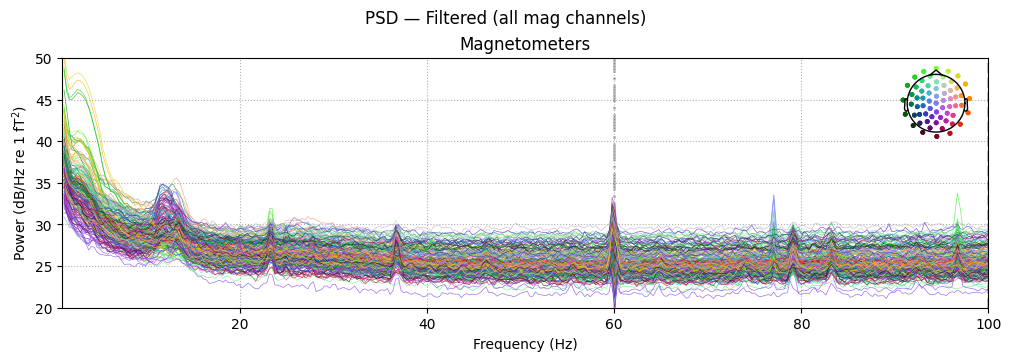

In [12]:
# Per-channel PSD for the filtered data — one line per channel.
# This is the standard MNE spectrum plot; it shows the spread across channels
# rather than the single channel-mean line in the comparison above.
# Useful for spotting noisy outlier channels (lines sitting well above the pack).

fig = spectrum_filt.plot(
    picks='mag',
    amplitude=False,
    dB=True,
    show=False,
)
fig.suptitle('PSD — Filtered (all mag channels)', fontsize=12)
# Clip axes
fig.axes[0].set_xlim(1, 100)
fig.axes[0].set_ylim(20, 50)  # adjust these bounds to taste
plt.show()

Z-axis channels for topomap: 62


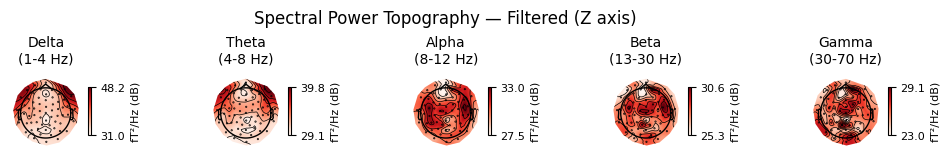

In [13]:
# Topomap uses the filtered spectrum — same sensor geometry as sections 2–5,
# and the cleaner signal makes spatial patterns easier to interpret.
# (True raw would show the same layout but noisier; ICA-clean would also work.)

bads_raw = set(raw.info['bads'])
z_picks_raw = [ch for ch in spectrum_filt.ch_names
               if ch.endswith(' Z') and not ch.startswith('BNC') and ch not in bads_raw]
print(f'Z-axis channels for topomap: {len(z_picks_raw)}')

spectrum_filt_z = spectrum_filt.copy().pick(z_picks_raw)

fig = spectrum_filt_z.plot_topomap(
    bands={
        'Delta\n(1-4 Hz)':   (1, 4),
        'Theta\n(4-8 Hz)':   (4, 8),
        'Alpha\n(8-12 Hz)':  (8, 12),
        'Beta\n(13-30 Hz)':  (13, 30),
        'Gamma\n(30-70 Hz)': (30, 70),
    },
    show=False,
    dB=True,
)
fig.suptitle('Spectral Power Topography — Filtered (Z axis)', fontsize=12)
plt.show()

---
## Part II — Epoched Data

Now that we've inspected the continuous recording, we move to the **preprocessed epochs**:
filtered, HFC-denoised, ICA-cleaned, and bad-epoch-rejected segments already cut around
stimulus onsets. These are the inputs for all ERP / MMN analysis.

## 7. Load the Epochs

We load the already-cleaned epochs. `preload=True` brings all the data into RAM upfront,
which is required for most visualization and analysis operations.

In [14]:
epochs = mne.read_epochs(epo_file, preload=True)
print(epochs)

<EpochsFIF | 988 events (all good), -0.5 – 0.8 s (baseline -0.2 – 0 s), ~862.1 MiB, data loaded, with metadata,
 'deviant_onset': 168
 'standard_onset': 820>


In [15]:
# Quick sanity check: how many epochs per condition?
# Expected before rejection: ~830 standards, ~170 deviants.
# After ICA + artifact rejection the actual counts will be somewhat lower.
for cond in epochs.event_id:
    n = len(epochs[cond])
    print(f'  {cond}: {n} epochs')

print(f'\nChannel types: {epochs.get_channel_types()[:3]}... ({len(epochs.ch_names)} total channels)')
print(f'Epoch window:  {epochs.tmin:.3f} s → {epochs.tmax:.3f} s')
print(f'Sampling rate: {epochs.info["sfreq"]} Hz')

  deviant_onset: 168 epochs
  standard_onset: 820 epochs

Channel types: ['stim', 'stim', 'stim']... (215 total channels)
Epoch window:  -0.500 s → 0.800 s
Sampling rate: 400.0 Hz


## 8. Visualize Epochs as Time Series — Deviant Trials Only

The most direct way to inspect epochs is `epochs.plot()`, which opens an interactive
browser where you can scroll through trials, zoom in/out, and flag bad epochs.

Here we plot **only the deviant trials** by indexing the epochs object with the condition label.
There are only ~160 deviant trials, separated from one another by
3–7 standard tones. Because they are rare, the brain's prediction-error response
(the **Mismatch Negativity, MMN**) is elicited at each one — making it worth inspecting
these trials closely for artifacts before averaging.

> **About blink trials:** A blink cue (green fixation cross, 1.5 s) follows each deviant at
> least 1100 ms after onset. Those blink-period epochs are *not* included in `deviant_onset` —
> they were triggered separately. So what you see here are clean stimulus-locked epochs
> that should be free of blink contamination within the MMN window.

**Interactive keyboard shortcuts** (best used in `%matplotlib qt` mode):
| Key | Action |
|-----|--------|
| `←` / `→` | Scroll epochs |
| `↑` / `↓` | Scroll channels |
| `+` / `-` | Zoom vertical scale |
| `b` | Toggle butterfly mode |
| Left-click epoch | Mark as bad |
| Left-click channel name | Mark channel as bad |

In [16]:
# Plot only the deviant condition epochs.
# In inline mode this shows a static snapshot; switch to %matplotlib qt for the
# full interactive browser.

fig = epochs[DEVIANT_COND].plot(
    n_epochs=5,      # show 5 epochs at a time
    n_channels=20,   # show 20 channels at a time
    title=f'Deviant epochs ({DEVIANT_COND})',
    show=True,
    block=False,     # don't block execution (set True in interactive Qt mode)
)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

## 9. Butterfly Mode — All Sensors Simultaneously

In a **butterfly plot** all channels of the same type are overlaid on a single axes,
making it easy to see the global waveform shape and spot outlier channels.

For OPM data, grouping by **sensor axis (X, Y, Z)** is more informative than `group_by='type'`
(which lumps everything together) or `group_by='position'` (which uses k-means clustering
and can produce empty groups). Each OPM slot records up to three orthogonal field components;
separating them into three butterfly panels lets you compare signal quality and artifact
character across axes — useful because movement artifacts often affect axes differently.

We build the grouping dict manually by parsing channel names for their axis suffix
(`[X]`, `[Y]`, `[Z]`). This gives **3 windows** — one per axis across all epochs.

> **What to look for:** Channels that sit far outside the pack (persistent outliers) are
> candidates for bad-channel marking. Correlated deflections across all three panels suggest
> a common-mode artifact (movement).


In [17]:
# Build a group_by dict that assigns each channel to its axis (X, Y, or Z).
# Channel names follow the pattern: LOCATION SERIAL AXIS  (e.g. 'Iz 1T Z', 'O10 1U X')
# BNC trigger channels (also ending in ' Z') are excluded by name prefix.

axis_groups = {'X': [], 'Y': [], 'Z': []}
ch_names = epochs.ch_names

for idx, ch in enumerate(ch_names):
    if ch.startswith('BNC'):
        continue  # skip trigger/BNC channels
    if ch.endswith(' X'):
        axis_groups['X'].append(idx)
    elif ch.endswith(' Y'):
        axis_groups['Y'].append(idx)
    elif ch.endswith(' Z'):
        axis_groups['Z'].append(idx)

# Remove any empty axes (e.g. if only radial Z channels were recorded)
axis_groups = {k: v for k, v in axis_groups.items() if v}

for ax, idxs in axis_groups.items():
    print(f'  {ax}: {len(idxs)} channels')

if not axis_groups:
    print('WARNING: No axis suffixes detected in channel names.')
    print('Sample names:', ch_names[:5])
    print('Falling back to group_by="type"')

  X: 66 channels
  Y: 66 channels
  Z: 66 channels


In [18]:
# Why .copy().pick('mag') instead of just using picks=?
# --------------------------------------------------------
# You might expect that passing picks=mag_indices to .plot() would be enough
# to show only magnetometer channels. It does filter *what is plotted*, but
# group_by='type' draws one row-label per channel type present in the epochs
# *object* — not just the ones selected by picks. So even if you only plot
# mag channels, the browser still renders empty rows for EOG, stim, eyetracking,
# pupil, and reference channels.
#
# The fix is to strip those other types out of the epochs object itself first
# using .pick('mag'). We use .copy() so the original epochs (with all channel
# types intact) is preserved for the other sections of this notebook.

epochs_mag = epochs.copy().pick('mag')

# Rebuild the axis index lists on the reduced channel set.
# After .pick('mag') the channel indices are renumbered from 0, so we can't
# reuse the axis_groups built earlier (those indices pointed into the full
# channel list). We rebuild using the same suffix logic as before.
axis_groups_mag = {'X': [], 'Y': [], 'Z': []}
for idx, ch in enumerate(epochs_mag.ch_names):
    if ch.endswith(' X'):
        axis_groups_mag['X'].append(idx)
    elif ch.endswith(' Y'):
        axis_groups_mag['Y'].append(idx)
    elif ch.endswith(' Z'):
        axis_groups_mag['Z'].append(idx)

# Gray lines in the butterfly plot are bad channels — MNE renders them in gray
# to distinguish them from good channels (shown in blue). They were flagged
# during preprocessing and stored in epochs.info['bads']. Run the line below
# to see which channels are marked bad:
print('Bad channels:', epochs_mag.info['bads'])

# Plot one butterfly window per axis — 3 windows total (all epochs, both conditions).
for axis, idxs in axis_groups_mag.items():
    epochs_mag.plot(
        picks=idxs,
        butterfly=True,
        group_by='type',
        title=f'Butterfly — {axis} axis ({len(idxs)} mag channels)',
        show=True,
        block=False,
    )


Bad channels: ['T14 1X Z', 'T14 1X Y', 'T14 1X X', 'F4 2N Z']


## 10. Sensor Layout — `plot_sensors()`

`epochs.plot_sensors()` draws sensor positions onto a head diagram. Two views are shown:

- **2D projection** (`kind='topomap'`, default) — flat overhead view useful for confirming layout at a glance
- **3D positions** (`kind='3d'`) — interactive rotatable view that reveals the helmet geometry and sensor depth; particularly useful for OPM arrays where sensors are form-fitted to the head

Both are a quick sanity check that:
- The digitisation / sensor geometry loaded correctly
- No sensors are in implausible locations
- Bad channels (if any) are visible as distinct markers

With `show_names=True` you can identify individual channel labels, which is helpful
when you want to pick a specific channel for targeted analysis.


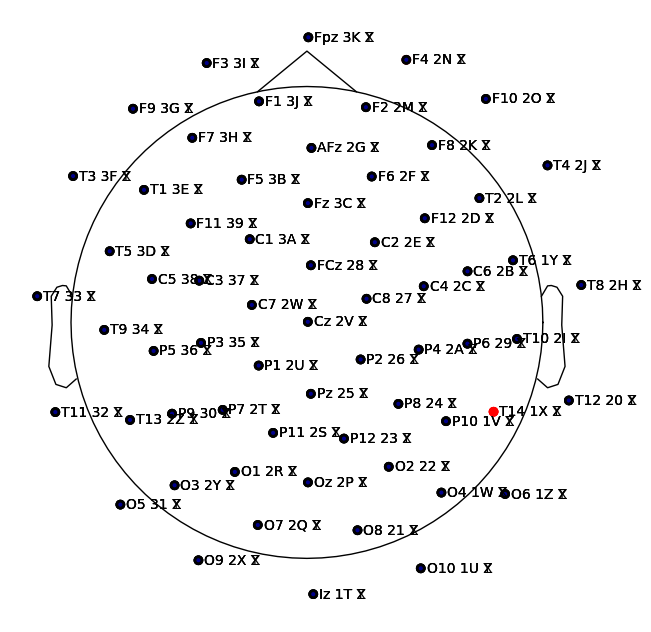

Text(0.5, 0.98, 'OPM Sensor Layout (labelled)')

In [19]:
# With channel names labelled — useful when you need to identify a specific sensor
fig = epochs.plot_sensors(show_names=True)
fig.suptitle('OPM Sensor Layout (labelled)', fontsize=12)

In [20]:
# make interactive
%matplotlib qt 


# 3D sensor positions — useful for OPM arrays where helmet geometry matters
# kind='3d' opens an interactive matplotlib 3D axes you can rotate
epochs.plot_sensors(kind='3d', show_names=False);




## 11. Power Spectral Density of Epochs

Before diving into time-domain waveforms it's worth looking at the **frequency content**
of the data. `epochs.compute_psd()` returns an `EpochsSpectrum` object. Calling `.plot()`
on it shows the mean PSD (with confidence interval) across epochs and channels.

For our OPM oddball data, key landmarks to check:
- **1/f slope** — MEG signals naturally have more power at low frequencies
- **60 Hz (and 120/180 Hz harmonics)** — power-line noise. These should have been
  notch-filtered during preprocessing, so a clean spectrum here is a good sign.
- **Low-frequency drift (<1 Hz)** — movement artifacts in OPM data tend to appear
  at very low frequencies; the epoch window and baseline period influence this

> **Note:** `compute_psd()` replaces the older `plot_psd()` method in MNE ≥ 1.2.

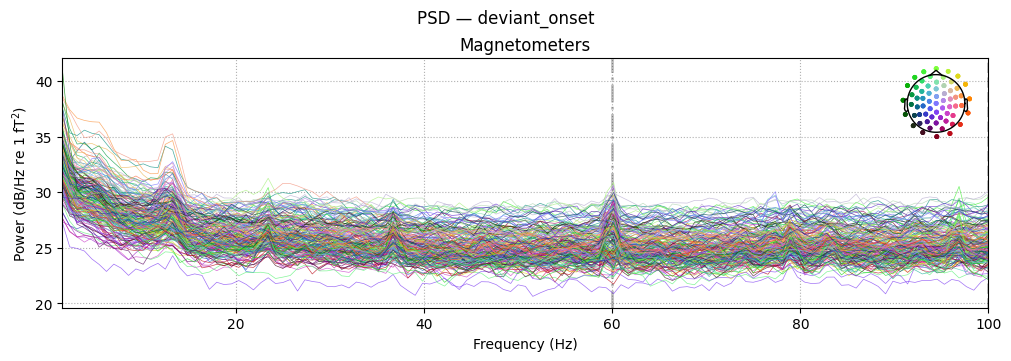

In [21]:
# A note on bad channels and explicit picks:
# MNE excludes bad channels by default only when picks=None. As soon as you
# pass an explicit picks argument (e.g. picks='mag'), bad channels that fall
# within that selection are included. We therefore pass exclude='bads' to
# compute_psd() so that flagged channels are consistently excluded here and
# in the overlay and topomap cells that follow.

# return to static
%matplotlib inline 


spectrum_deviant = epochs[DEVIANT_COND].compute_psd(
    method='welch',
    fmin=1.0,
    fmax=100.0,
    n_fft=512,
    n_overlap=256,
    exclude='bads',   # exclude channels marked bad during preprocessing
)

# .plot() shows mean PSD ± CI across epochs, one line per channel.
# show=False suppresses MNE's internal plt.show() call, which triggers a
# harmless but noisy UserWarning in inline/notebook backends.
# MNE's PSD figure uses a custom axes layout that is incompatible with
# tight_layout(), so we skip that call here — the figure renders correctly without it.
fig = spectrum_deviant.plot(
    picks='mag',        # OPM sensors are mag-type
    amplitude=False,    # plot power (T²/Hz) not amplitude (T/√Hz)
    dB=True,            # log scale: easier to see broadband structure
    show=False,
)
fig.suptitle(f'PSD — {DEVIANT_COND}', fontsize=12)
plt.show()


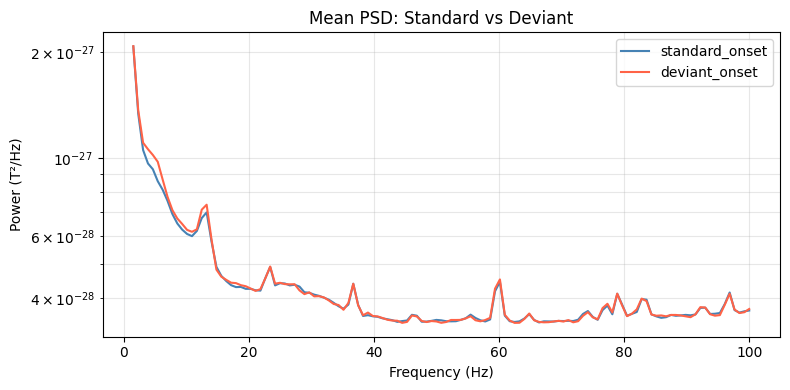

In [22]:
# Overlay both conditions to compare spectral profiles.
#
# Note on trial counts: compute_psd() calculates a spectrum for each epoch
# individually and then averages them, so every trial contributes equally to
# the mean. The difference in trial counts (~830 standard vs ~170 deviant)
# does NOT bias the mean PSD — a condition with 10x more trials gives the
# same mean PSD as one with fewer trials if the underlying signal is the same.

spectrum_standard = epochs[STANDARD_COND].compute_psd(
    method='welch', fmin=1.0, fmax=100.0, n_fft=512, n_overlap=256,
    exclude='bads',   # exclude bad channels, consistent with spectrum_deviant above
)

fig, ax = plt.subplots(figsize=(8, 4))

for spec, label, color in [
    (spectrum_standard, STANDARD_COND, 'steelblue'),
    (spectrum_deviant,  DEVIANT_COND,  'tomato'),
]:
    psds, freqs = spec.get_data(return_freqs=True)  # shape: (n_epochs, n_ch, n_freqs)
    mean_psd = psds.mean(axis=(0, 1))               # average over epochs and channels
    ax.semilogy(freqs, mean_psd, label=label, color=color, linewidth=1.5)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (T²/Hz)')
ax.set_title('Mean PSD: Standard vs Deviant')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()


## 12. Spectral Power as Scalp Topography — `plot_topomap()`

`EpochsSpectrum.plot_topomap()` shows **where on the scalp** the power lives within
each canonical frequency band. By default it plots five bands:

| Band | Range |
|------|-------|
| δ (delta) | 1–4 Hz |
| θ (theta) | 4–8 Hz |
| α (alpha) | 8–12 Hz |
| β (beta) | 13–30 Hz |
| γ (low gamma/high gamma) | 30–70/70-150 Hz |

For auditory oddball MEG data, power differences between conditions are expected
to be strongest over **bilateral temporal regions** (superior temporal gyrus, auditory
cortex), where the MMN generators are located. Unlike EEG — where the MMN appears
as a frontocentral negativity at Fz/FCz — MEG is sensitive to the tangential current
sources in the supratemporal plane, making temporal sensors the most informative here.


Using 62 Z-axis channels for topomaps


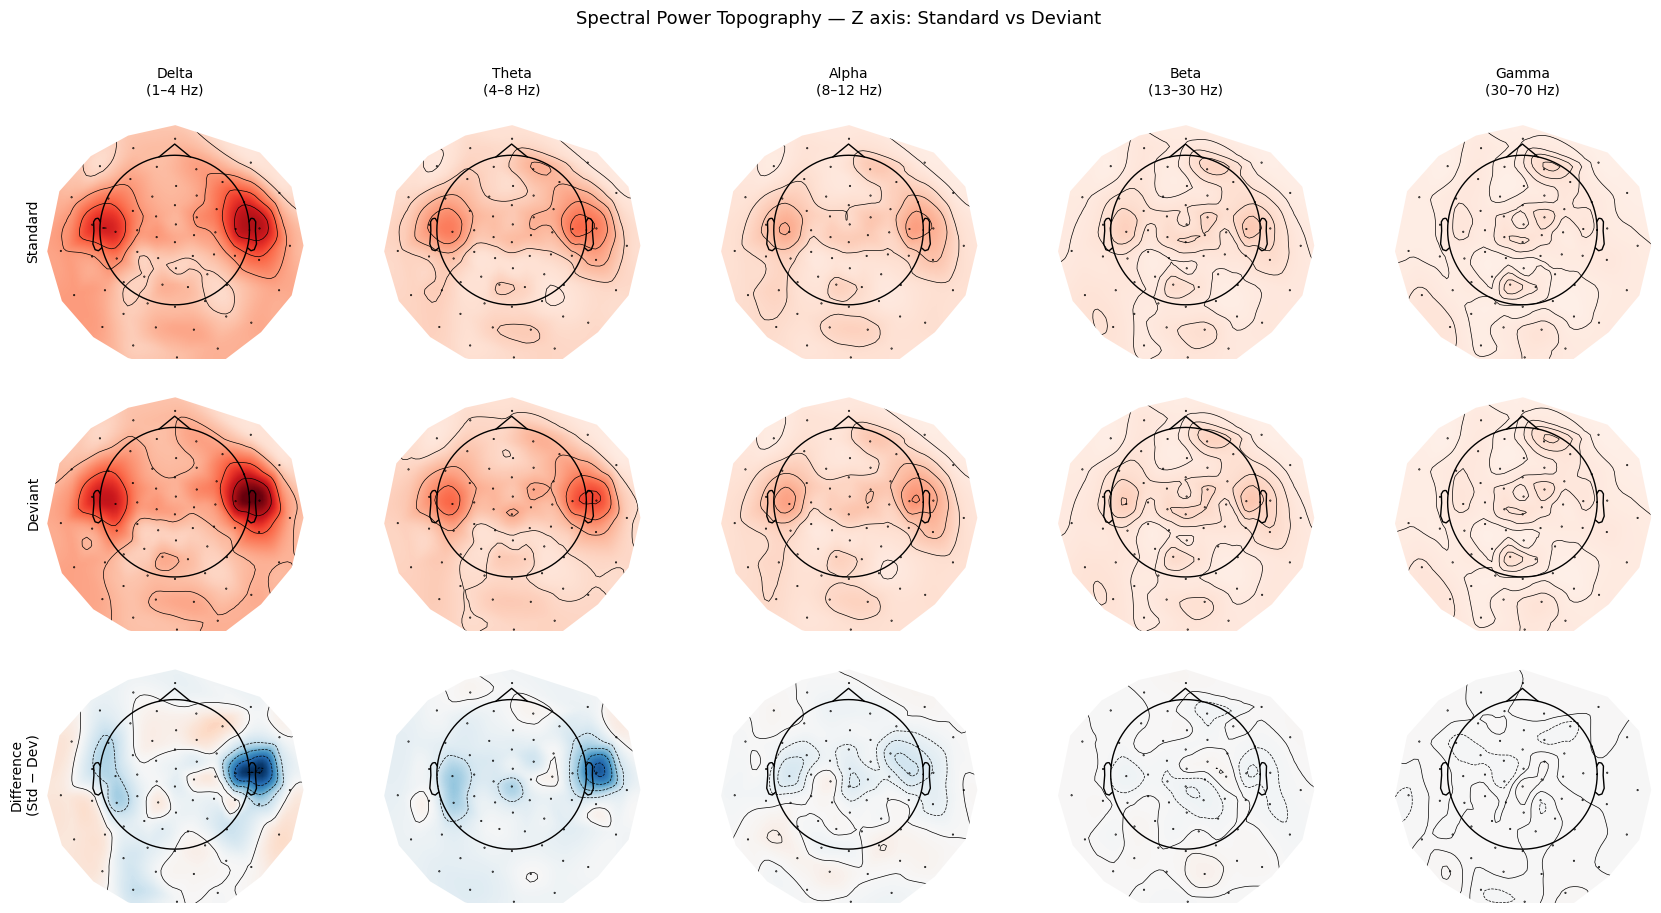

In [24]:
# ── Settings ─────────────────────────────────────────────────────────────────
SHARED_COLORSCALE = True   # True: Standard and Deviant rows share the same colorscale
                           # False: each row scaled independently to its own maximum

# Plot spectral power topographies for both conditions and their difference.
#
# Important: X, Y, and Z channels for each sensor slot share the same 3D
# position — they are co-located by design (three orthogonal axes measured
# at the same physical point). plot_topomap() requires one unique spatial
# location per data point, so passing all three axes at once raises a
# 'overlapping positions' error.
#
# The fix is to use only one axis per topomap. We use Z (radial, normal to
# the scalp surface) as it typically has the highest SNR for MEG signals.
#
# EpochsSpectrum.plot_topomap() doesn't support a difference row, so we
# build the figure manually using mne.viz.plot_topomap().
#

import numpy as np

# Restrict to Z-axis mag channels only, excluding any bad channels.
bads = set(spectrum_deviant.info['bads'])
z_picks = [i for i, ch in enumerate(spectrum_deviant.ch_names)
           if ch.endswith(' Z') and not ch.startswith('BNC') and ch not in bads]
print(f'Using {len(z_picks)} Z-axis channels for topomaps')
if bads:
    print(f'Excluded bad channels: {[ch for ch in bads if ch.endswith(" Z")]}')

# Standard frequency bands
bands = [
    (1,  4,   'Delta\n(1–4 Hz)'),
    (4,    8,   'Theta\n(4–8 Hz)'),
    (8,    12,  'Alpha\n(8–12 Hz)'),
    (13,   30,  'Beta\n(13–30 Hz)'),
    (30,   70,  'Gamma\n(30–70 Hz)'),
]
n_bands = len(bands)

def mean_band_power(spectrum, picks, fmin, fmax):
    """Average power (linear) across epochs and across the frequency band.
    Returns shape (n_channels,) — one value per channel, for use in plot_topomap."""
    psds, freqs = spectrum.get_data(picks=picks, return_freqs=True)
    mask = (freqs >= fmin) & (freqs <= fmax)
    return psds[:, :, mask].mean(axis=(0, 2))  # (n_channels,)

# Compute per-band power for each condition
std_bands  = np.array([mean_band_power(spectrum_standard, z_picks, fmin, fmax)
                       for fmin, fmax, _ in bands])   # (n_bands, n_z_channels)
dev_bands  = np.array([mean_band_power(spectrum_deviant,  z_picks, fmin, fmax)
                       for fmin, fmax, _ in bands])
diff_bands = std_bands - dev_bands                    # positive = standard > deviant

# Build a single-axis info object for plot_topomap (Z channels only)
info_z = mne.pick_info(spectrum_deviant.info, z_picks)

# ── Colorscale ───────────────────────────────────────────────────────────────
# When SHARED_COLORSCALE=True, Standard and Deviant rows share a single vmax
# (the max across both), so their colors are directly comparable.
# The Difference row always uses its own diverging scale centered at zero.
# When False, each row scales independently to its own maximum.
if SHARED_COLORSCALE:
    shared_vmax = max(np.abs(std_bands).max(), np.abs(dev_bands).max())
else:
    shared_vmax = None

# ── Colormap notes ───────────────────────────────────────────────────────────
# Standard and Deviant rows use 'Reds' (white → red): higher power = deeper red.
# Difference row uses 'RdBu_r' (diverging, centered at zero):
#   Red  = standard > deviant  (more power in standard)
#   Blue = deviant > standard  (more power in deviant)

row_labels = ['Standard', 'Deviant', 'Difference\n(Std − Dev)']
row_data   = [std_bands, dev_bands, diff_bands]

fig, axes = plt.subplots(3, n_bands, figsize=(3.5 * n_bands, 9))

for row_idx, (row_label, data) in enumerate(zip(row_labels, row_data)):
    if row_idx == 2:
        # Difference row: always its own diverging scale
        vmax = np.abs(data).max()
        vmin = -vmax
        cmap = 'RdBu_r'
    else:
        # Standard / Deviant rows
        vmax = shared_vmax if SHARED_COLORSCALE else np.abs(data).max()
        vmin = 0
        cmap = 'Reds'

    for col_idx, (band_label, band_data) in enumerate(zip([b[2] for b in bands], data)):
        ax = axes[row_idx, col_idx]
        mne.viz.plot_topomap(
            band_data,
            info_z,
            axes=ax,
            show=False,
            cmap=cmap,
            vlim=(vmin, vmax),
            sensors=True,
            contours=4,
        )
        if row_idx == 0:
            ax.set_title(band_label, fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=10)

fig.suptitle('Spectral Power Topography — Z axis: Standard vs Deviant', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 13. Epoch Image Map — `plot_image()`

An **epoch image** is one of the most informative single-channel visualizations available.
It stacks all trials as rows of pixels:

- **X-axis:** time (within the epoch window)
- **Y-axis:** trial number (each row = one epoch, in acquisition order)
- **Color:** signal amplitude at that time × trial
- **Bottom panel:** mean ERP ± 95% bootstrapped confidence interval

This makes it easy to:
1. Spot **single-trial artifacts** (bright/dark horizontal streaks)
2. See whether the response is **consistent across trials** (a coherent vertical band)
3. Identify **trial-by-trial drift** (gradual color shift from top to bottom, indicating
   non-stationarity over the ~24 min recording)

### What to expect for the MMN in OPM MEG

The MMN is generated in **bilateral auditory cortex** (superior temporal gyrus and
Heschl's gyrus, in the supratemporal plane). In MEG, this manifests as a characteristic
**dipolar magnetic field pattern** over each temporal lobe — not the frontocentral
negativity seen in EEG, which reflects the same sources projected differently onto
the scalp surface. The channel we plot here (`T13 2Z Z`) sits over left temporal
cortex and should show this response directly.

**Temporal window:** The MMN peaks within **100–250 ms** after deviant onset. Several
factors influence where in that window the peak falls:

| Factor | Effect on MMN latency |
|--------|----------------------|
| Magnitude of deviance (frequency, duration, intensity) | Larger deviance → earlier, stronger MMN |
| ISI | Longer ISI → later MMN |
| Participant age | Older participants → longer latency |
| Attention state | Passive listening can shift latency relative to active tasks |

For this paradigm (200 Hz frequency shift, ~800 ms mean ISI, passive fixation), expect
the peak somewhere in the **130–200 ms** range.


Single-trial MMN visibility is limited — SNR is typically ~0.1–0.3 per trial — so
the response will be clearest in the mean ERP panel at the bottom of the image,
not in individual trial rows.

> **Tip:** The epoch window extends well past the tone offset (400 ms) to capture the
> full MMN and any later components. The ISI jitter (700–900 ms) means there is no
> stimulus-locked activity after ~900 ms post-onset, so the late portion of the epoch
> serves as a useful noise reference.


Plotting image for channel: T13 2Z Z


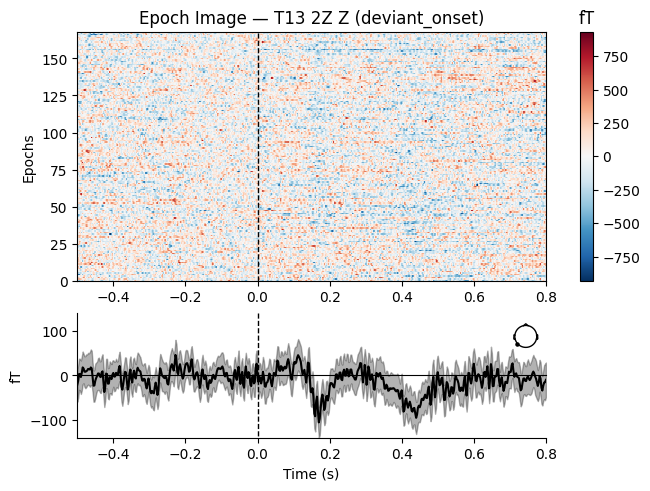

In [25]:
# Pick one representative sensor to start with.
# You can change this to any channel name in epochs.ch_names.
# Check plot_sensors() above to identify channel locations.

example_channel = 'T13 2Z Z'  # left temporal — shows a clear MMN response
print(f'Plotting image for channel: {example_channel}')

fig = epochs[DEVIANT_COND].plot_image(
    picks=example_channel,
    sigma=0.5,          # light Gaussian smoothing across trials (reduces visual noise)
    title=f'Epoch Image — {example_channel} ({DEVIANT_COND})',
)


Deviant trials:               168
Standard trials (original):   820
Standard trials (subsampled): 168
Shared colorscale: vmin=-6.206e-13, vmax=6.206e-13 T


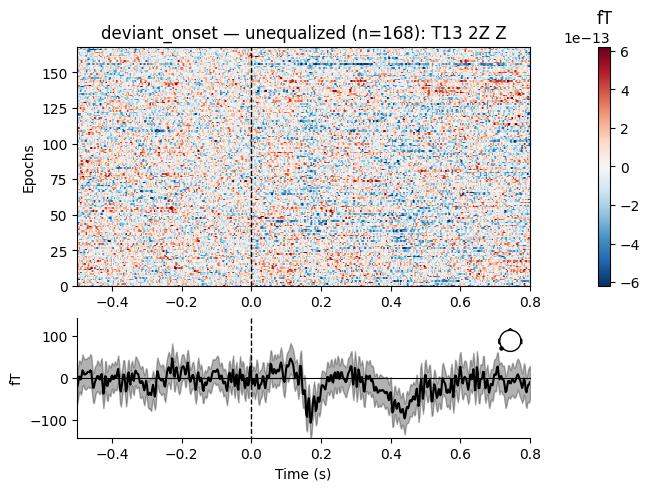

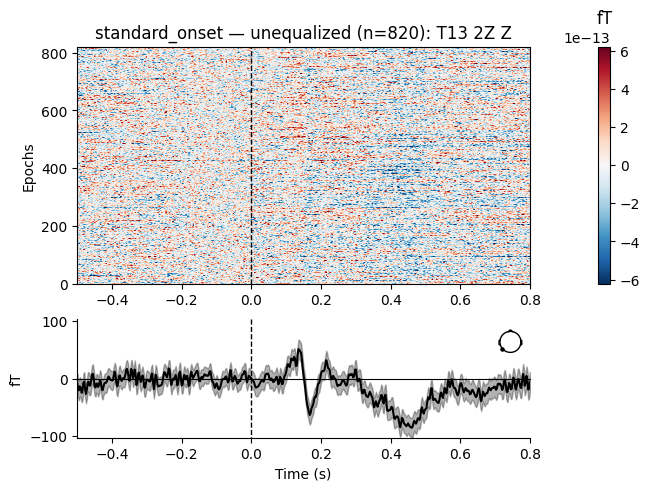

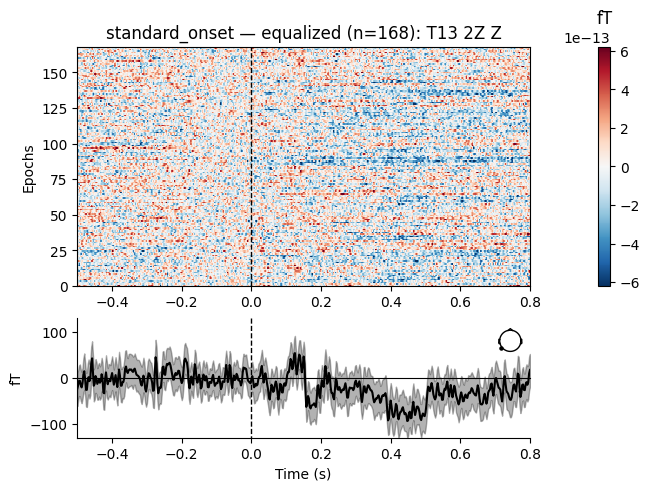

In [26]:
# ── Settings ─────────────────────────────────────────────────────────────────
SHARED_COLORSCALE = True   # True: same vmin/vmax across all 3 plots (fair comparison)
                           # False: MNE chooses independently per plot (maximises contrast)

# ── Equalized subsample (computed once, reused below) ────────────────────────
rng = np.random.default_rng(seed=42)
n_deviant  = len(epochs[DEVIANT_COND])
n_standard = len(epochs[STANDARD_COND])
subsample_idx  = rng.choice(n_standard, size=n_deviant, replace=False)
epochs_std_sub = epochs[STANDARD_COND][subsample_idx]

print(f'Deviant trials:               {n_deviant}')
print(f'Standard trials (original):   {n_standard}')
print(f'Standard trials (subsampled): {len(epochs_std_sub)}')

# ── Three figures ─────────────────────────────────────────────────────────────
# 1. Deviant — unequalized (all deviant trials, for reference)
# 2. Standard — unequalized (all standard trials; note the tighter CI vs deviant)
# 3. Standard — equalized (subsampled to match deviant N; CI should widen to match)
#
# Comparing figures 1 and 2 shows the CI difference due to unequal trial counts.
# Comparing figures 1 and 3 gives a fair comparison of response variability.

plots = [
    (epochs[DEVIANT_COND],  f'{DEVIANT_COND} — unequalized (n={n_deviant})'),
    (epochs[STANDARD_COND], f'{STANDARD_COND} — unequalized (n={n_standard})'),
    (epochs_std_sub,        f'{STANDARD_COND} — equalized (n={len(epochs_std_sub)})'),
]

# ── Shared colorscale ─────────────────────────────────────────────────────────
# When SHARED_COLORSCALE=True, compute vmin/vmax from the 99th percentile of
# absolute values pooled across all three epoch sets, then apply the same limits
# to every plot.  This makes amplitude differences visible across figures.
# When False, MNE chooses its own scale per plot — maximises within-plot contrast
# but makes cross-plot amplitude comparisons unreliable.
if SHARED_COLORSCALE:
    all_data = np.concatenate([
        epo.copy().pick(example_channel).get_data()
        for epo, _ in plots
    ], axis=0)
    vmax = float(np.percentile(np.abs(all_data), 99))
    vmin = -vmax
    print(f'Shared colorscale: vmin={vmin:.3e}, vmax={vmax:.3e} T')
else:
    vmin = vmax = None   # let MNE decide per plot
    print('Independent colorscale per plot (MNE default)')

for epo, title in plots:
    epo.plot_image(
        picks=example_channel,
        sigma=0.5,
        vmin=vmin,
        vmax=vmax,
        scalings=dict(mag=1.),
        title=f'{title}: {example_channel}',
        show=False,
    )
    plt.show()

> **Tip:** You can sort epochs by an external variable using the `order` parameter.
> For example, sorting by trial index (acquisition time) can reveal slow drift across the
> ~24 min recording session. Sorting by deviant position within a run (early vs late standards
> preceding the deviant) could reveal refractoriness effects:
> ```python
> # Sort deviant epochs by their original trial index
> trial_indices = epochs[DEVIANT_COND].selection  # original indices in the full events array
> sort_order = np.argsort(trial_indices)           # already sorted, but useful as a template
> epochs[DEVIANT_COND].plot_image(picks=example_channel, order=sort_order)
> ```

## 14. Topographic Image Map — `plot_topo_image_epochs()`

`plot_topo_image_epochs()` extends the image map concept to **all sensors simultaneously**,
rendering a miniature epoch image at each sensor's location on a head diagram.

This lets you see at a glance:
- Which **regions of the scalp** show the strongest response
- Whether the MMN signal shows the expected **bilateral temporal distribution** —
  in MEG, the response is maximal over auditory cortex on both sides, appearing as
  opposing magnetic field polarities on either side of each temporal lobe. This is distinct
   from EEG, where the MMN appears frontocentrally at Fz.
- Whether any **spatial clusters** of sensors show anomalous patterns
  (e.g., sensors near the ears picking up muscle noise)
- How the **standard and deviant** responses differ across the whole sensor array

Since OPM data has a single channel type (unlike SQUID MEG which has separate
magnetometers and gradiometers), we don't need to filter by channel type or pass
a layout object — MNE will use the digitized sensor positions directly.

In [27]:
# First, drop any remaining outlier epochs that could dominate the colorscale.
# We use a simple peak-to-peak amplitude threshold.

# Compute peak-to-peak per epoch per channel
# get_data() has no exclude argument — pick first to drop bad channels,
# then call get_data().  Bad channels often have extreme amplitudes that
# would inflate the ptp threshold and cause good epochs to be incorrectly dropped.
data = epochs[DEVIANT_COND].copy().pick('mag', exclude='bads').get_data()  # (n_epochs, n_ch, n_times)
ptp  = np.ptp(data, axis=-1).max(axis=-1)            # max p-t-p across channels, per epoch

threshold_pT = np.percentile(ptp, 95)                # 95th percentile as threshold
good_mask    = ptp < threshold_pT

print(f'Keeping {good_mask.sum()} / {len(good_mask)} deviant epochs '
      f'(threshold: {threshold_pT*1e12:.1f} pT peak-to-peak)')

epochs_deviant_clean = epochs[DEVIANT_COND][good_mask]


Keeping 159 / 168 deviant epochs (threshold: 3.2 pT peak-to-peak)


In [28]:
# plot_topo_image_epochs: one mini epoch-image at each sensor location.
# NOTE: do NOT use `from mne.viz import ...` here — that triggers a fresh import
# resolution which can pick up a different MNE installation (e.g. miniconda).
# Instead, access through the `mne` object already imported in Cell 2, which is
# bound to the correct uv environment.

# make interactive
%matplotlib qt 

plot_topo_image_epochs = mne.viz.plot_topo_image_epochs

# plot_topo_image_epochs has no picks argument — pre-select mag channels first.
# This is essential: non-mag channels (eyetracking, BNC, stim) have completely
# different amplitude scales and will ruin MNE's auto-colorscaling if included.
# exclude='bads' also removes any channels flagged in epochs.info['bads'].
epochs_mag = epochs_deviant_clean.copy().pick('mag', exclude='bads')

fig = plot_topo_image_epochs(
    epochs_mag,
    sigma=1.0,
    title=f'Topo Image — {DEVIANT_COND}',
    show=True,
)


## 15. Summary

Here's a quick reference for what each visualization is best suited for:

### Part I — Continuous raw data

| Method | Best for |
|--------|----------|
| `raw.info` / attribute queries | Checking recording parameters, channel counts, filter history |
| `mne.events_from_annotations()` / `mne.find_events()` | Extracting event structure; verifying trial counts |
| `mne.viz.plot_events()` | Static raster of all events on a timeline; paradigm sanity check |
| `raw.plot(events=..., picks='mag')` | Interactive scrollable browser; spotting transients, drift, bad channels |
| `raw.compute_psd().plot()` | Broadband spectral fingerprint of the whole recording; notch filter check |
| `spectrum.plot_topomap()` (raw) | Where on the scalp each frequency band lives in continuous data |

### Part II — Epoched data

| Method | Best for |
|--------|----------|
| `epochs.plot()` | Interactive artifact inspection; marking bad epochs/channels |
| `epochs.plot(butterfly=True, group_by=axis_groups)` | Global waveform shape per field axis (X/Y/Z) |
| `epochs.plot_sensors()` | Confirming 2D layout and 3D helmet geometry |
| `spectrum.plot()` | Verifying filter settings; checking 60 Hz line noise / sensor noise floor |
| `spectrum.plot_topomap()` | Spatial distribution of spectral power per frequency band |
| `epochs.plot_image()` | Single-channel trial-by-trial consistency; drift over ~24 min session |
| `plot_topo_image_epochs()` | Spatial overview of trial structure across all sensors |

### What to expect in this dataset

- **MMN window:** 100–250 ms post-onset (expect peak ~130–200 ms for this paradigm)
- **MMN distribution:** bilateral temporal in MEG (superior temporal gyrus / Heschl's gyrus);
  note this differs from EEG where the MMN appears frontocentrally at Fz
- **Standard vs deviant:** ~830 vs ~170 trials (after preprocessing rejection, somewhat fewer)
- **Tone offset:** 400 ms — any activity past this reflects post-stimulus processing,
  not the acoustic onset response
- **Blink trials** (green fixation, ≥1100 ms post-deviant) are separate events and
  do not appear in `deviant_onset` epochs

### Next steps
- The evoked data structure
- Visualizing evoked data
- Time frequency analysis
- Source localization
